# 🧠 Deep Learning from Scratch /Section 4
# Convolutional Neural Networks (CNN)
---
**Builds on:** Sections 1–3  
**Goal:** Implement convolution, pooling, and a minimal CNN from scratch in NumPy.

---
## 📌 Table of Contents
1. [Intuition](#intuition)
2. [Convolution Mathematics](#math)
3. [conv2d from Scratch](#conv)
4. [Max Pooling](#pool)
5. [Multi-Channel Convolution (im2col)](#multi)
6. [MinimalCNN Architecture](#arch)
7. [Experiment: Image Classification](#exp)


## 1. Intuition <a id="intuition"></a>

### Why Not Just Use an MLP on Images?

A 28×28 image has 784 pixels. A fully connected layer with 512 hidden neurons needs **784 × 512 = 400k parameters** just for one layer — and ignores all spatial structure.

### The CNN Insight

Instead, we **slide a small filter** across the image:
- Each filter is $k \times k$ (e.g. 3×3 = 9 parameters)
- It detects a local pattern (edge, corner, blob) **wherever it appears**
- This is called **translation equivariance**

```
  Image patch (3×3)      Filter (3×3)       Output value
  ┌───────────────┐   ×  ┌─────────────┐  =  scalar
  │  0  0  0      │      │ -1  0  +1   │
  │  0  1  0      │      │ -2  0  +2   │      (edge detector!)
  │  0  0  0      │      │ -1  0  +1   │
  └───────────────┘      └─────────────┘
```

Multiple filters detect different patterns in parallel, producing a **feature map** per filter.


## 2. Convolution Mathematics <a id="math"></a>

Given:
- Input $I$ of shape $(H, W)$
- Filter/kernel $K$ of shape $(k, k)$
- Padding $P$, Stride $S$

Output value at position $(i, j)$:
$$O[i,j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I[i \cdot S + m,\; j \cdot S + n] \cdot K[m, n]$$

Output shape:
$$H_{out} = \left\lfloor \frac{H - k + 2P}{S} \right\rfloor + 1, \quad W_{out} = \left\lfloor \frac{W - k + 2P}{S} \right\rfloor + 1$$

### Key parameters:
| Parameter | Effect |
|---|---|
| **Padding $P=0$** | Output shrinks by $k-1$ in each dimension |
| **Padding $P=(k-1)/2$** | "Same" padding — output same size as input |
| **Stride $S=1$** | Dense scanning — every position |
| **Stride $S=2$** | Downsampling — halves spatial dimensions |


In [4]:
# ── Install / import dependencies ────────────────────────────────────────────
# This notebook uses ONLY numpy + matplotlib — no deep learning frameworks.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── Dark plot style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#c8ccd8",
    "ytick.color":      "#c8ccd8",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "font.family":      "monospace",
})

ACCENT = "#7c83ff"
GREEN  = "#56d364"
ORANGE = "#ffa657"
PINK   = "#f778ba"
YELLOW = "#e3b341"

print("Setup complete — NumPy", np.__version__)


Setup complete — NumPy 2.0.2


In [5]:
# activation functions 

def relu(z):
    """ReLU: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """d/dz ReLU = 1 if z > 0 else 0"""
    return (z > 0).astype(float)

def sigmoid(z):
    """Numerically-stable sigmoid: σ(z) = 1 / (1 + e^{-z})"""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_derivative(z):
    """dσ/dz = σ(z)(1 − σ(z))"""
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    """Softmax — numerically stable (subtract row max before exp)."""
    z_s   = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_s)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)




## 3. `conv2d` from Scratch <a id='conv'></a>

In [6]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    2-D cross-correlation (what deep learning calls "convolution").

    Parameters
    ----------
    image   : np.ndarray  shape (H, W)
    kernel  : np.ndarray  shape (kH, kW)
    stride  : int         step size
    padding : int         zeros added to each border

    Returns
    -------
    output  : np.ndarray  shape (H_out, W_out)
    """
    H, W   = image.shape
    kH, kW = kernel.shape

    if padding > 0:
        image = np.pad(image, pad_width=padding, mode="constant", constant_values=0)

    H_p, W_p = image.shape
    H_out = (H_p - kH) // stride + 1
    W_out = (W_p - kW) // stride + 1
    output = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            # Extract receptive field patch
            patch = image[i*stride : i*stride+kH,
                          j*stride : j*stride+kW]
            # Dot product with kernel (Frobenius inner product)
            output[i, j] = np.sum(patch * kernel)

    return output




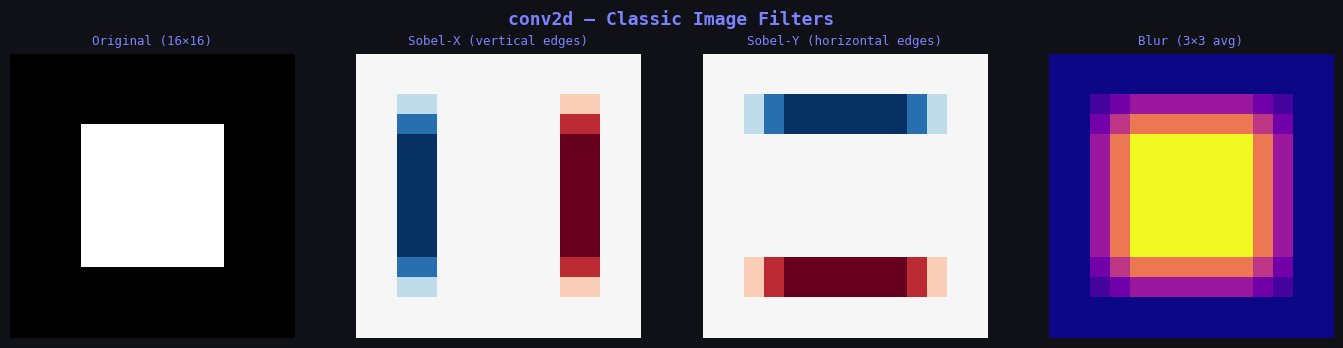

In [7]:
#  Demonstrate classic edge-detection filters on a synthetic image 
np.random.seed(0)
test_img = np.zeros((16, 16))
test_img[4:12, 4:12] = 1.0    # white square in the middle

# Sobel-X: detects vertical edges
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=float)

# Sobel-Y: detects horizontal edges
sobel_y = np.array([[-1,-2,-1],
                     [ 0, 0, 0],
                     [ 1, 2, 1]], dtype=float)

# Blur / averaging filter
blur = np.ones((3, 3)) / 9.0

out_sx = conv2d(test_img, sobel_x)
out_sy = conv2d(test_img, sobel_y)
out_bl = conv2d(test_img, blur)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("conv2d — Classic Image Filters", fontsize=13,
             color=ACCENT, fontweight="bold")

titles = ["Original (16×16)", "Sobel-X (vertical edges)",
          "Sobel-Y (horizontal edges)", "Blur (3×3 avg)"]
imgs   = [test_img, out_sx, out_sy, out_bl]
cmaps  = ["gray", "RdBu", "RdBu", "plasma"]

for ax, title, im, cm in zip(axes, titles, imgs, cmaps):
    ax.set_facecolor("#1a1d27")
    ax.imshow(im, cmap=cm)
    ax.set_title(title, color=ACCENT, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. Max Pooling <a id='pool'></a>

In [8]:
def max_pool2d_batch(X, pool_size=2, stride=2):
    """
    Vectorised max pooling over a batch.

    Takes the maximum value in each pool_size×pool_size window.
    This reduces spatial dimensions and provides rough translation invariance.

    Parameters
    ----------
    X         : np.ndarray  shape (N, C, H, W)
    pool_size  : int
    stride    : int

    Returns
    -------
    out       : np.ndarray  shape (N, C, H_out, W_out)
    """
    N, C, H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    out   = np.zeros((N, C, H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            patch = X[:, :,
                      i*stride : i*stride+pool_size,
                      j*stride : j*stride+pool_size]
            out[:, :, i, j] = patch.max(axis=(2, 3))   # max over spatial dims

    return out




## 5. Multi-Channel Convolution (im2col) <a id='multi'></a>

For efficiency, we **unroll** all filter positions into a matrix multiplication using the **im2col** trick.

In [9]:
def conv2d_multichannel(X, filters, stride=1, padding=0):
    """
    Batched multi-channel convolution via im2col.

    im2col: extract every receptive-field patch into a column vector,
    then the entire convolution becomes one matrix multiplication.

    Parameters
    ----------
    X       : np.ndarray  shape (N, C_in, H, W)
    filters : np.ndarray  shape (C_out, C_in, kH, kW)

    Returns
    -------
    output  : np.ndarray  shape (N, C_out, H_out, W_out)
    """
    N, C_in, H, W    = X.shape
    C_out, _, kH, kW = filters.shape

    if padding > 0:
        X = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)))

    H_p, W_p = X.shape[2], X.shape[3]
    H_out = (H_p - kH) // stride + 1
    W_out = (W_p - kW) // stride + 1


    cols = np.zeros((N, C_in * kH * kW, H_out * W_out))
    idx = 0
    for ci in range(C_in):
        for ki in range(kH):
            for kj in range(kW):
                cols[:, idx, :] = X[:, ci,
                                    ki:ki+stride*H_out:stride,
                                    kj:kj+stride*W_out:stride].reshape(N, -1)
                idx += 1

    # filters → (C_out, C_in*kH*kW)
    f   = filters.reshape(C_out, C_in * kH * kW)
    # Matrix multiply per sample: (C_out, patch_size) × (patch_size, H_out*W_out)
    out = np.stack([f @ cols[n] for n in range(N)])   # (N, C_out, H_out*W_out)
    return out.reshape(N, C_out, H_out, W_out)




## 6. MinimalCNN Architecture <a id='arch'></a>

In [10]:
class MinimalCNN:
    """
    Minimal 2-block CNN for 16×16 single-channel images.

    Architecture:
        Conv(1→8,  3×3) → ReLU → MaxPool(2×2)   [16→14→7]
        Conv(8→16, 3×3) → ReLU → MaxPool(2×2)   [7→5→2]
        Flatten(64) → FC(64→64) → ReLU → FC(64→n_classes) → Softmax
    """

    def __init__(self, n_classes=3, lr=0.005):
        self.lr = lr

        # Convolutional filters
        self.F1 = np.random.randn(8, 1, 3, 3) * 0.1    # 8 filters, 3×3
        self.b1 = np.zeros(8)
        self.F2 = np.random.randn(16, 8, 3, 3) * 0.1   # 16 filters, 3×3
        self.b2 = np.zeros(16)

        # Fully connected layers (64 = 16 channels × 2×2 spatial)
        self.W3 = np.random.randn(64, 64) * np.sqrt(2.0 / 64)
        self.b3 = np.zeros((1, 64))
        self.W4 = np.random.randn(64, n_classes) * np.sqrt(2.0 / 64)
        self.b4 = np.zeros((1, n_classes))

    def forward(self, X):
        """X: (N, 1, 16, 16)"""
        N = X.shape[0]

        # Conv block 1
        self.c1 = conv2d_multichannel(X, self.F1) + self.b1[None,:,None,None]
        self.r1 = relu(self.c1)                         # (N, 8, 14, 14)
        self.p1 = max_pool2d_batch(self.r1, 2, 2)       # (N, 8,  7,  7)

        # Conv block 2
        self.c2 = conv2d_multichannel(self.p1, self.F2) + self.b2[None,:,None,None]
        self.r2 = relu(self.c2)                         # (N, 16, 5, 5)
        self.p2 = max_pool2d_batch(self.r2, 2, 2)       # (N, 16, 2, 2)

        # Flatten + FC
        self.flat = self.p2.reshape(N, -1)              # (N, 64)
        self.Z3   = self.flat @ self.W3 + self.b3
        self.A3   = relu(self.Z3)
        self.Z4   = self.A3 @ self.W4 + self.b4
        self.A4   = softmax(self.Z4)
        return self.A4

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)




## 7. Experiment: Synthetic Image Classification <a id='exp'></a>

Dataset: (30, 1, 16, 16)


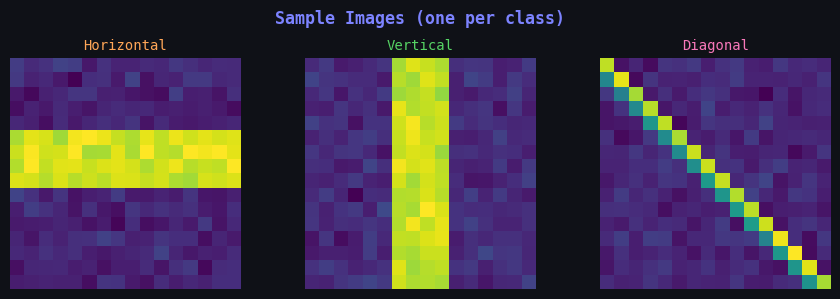

In [11]:
def make_synthetic_images(n_per_class=10, img_size=16):
    """
    3 clearly-distinguishable classes at 16×16:
      Class 0 → horizontal stripe
      Class 1 → vertical stripe
      Class 2 → diagonal line
    """
    images, labels = [], []
    for cls in range(3):
        for _ in range(n_per_class):
            img = np.random.randn(img_size, img_size) * 0.1
            if cls == 0:
                row = np.random.randint(4, img_size - 4)
                img[row-2:row+2, :] += 2.0
            elif cls == 1:
                col = np.random.randint(4, img_size - 4)
                img[:, col-2:col+2] += 2.0
            else:
                for k in range(img_size):
                    img[k, k] += 2.0
                    if k > 0: img[k, k-1] += 1.0
            images.append(img)
            labels.append(cls)
    return np.array(images)[:, None, :, :], np.array(labels)

X_img, y_img = make_synthetic_images(n_per_class=10, img_size=16)
print(f"Dataset: {X_img.shape}")

# ── Show one sample from each class ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Sample Images (one per class)", color=ACCENT, fontsize=12, fontweight="bold")
for cls_i in range(3):
    ax = axes[cls_i]
    ax.set_facecolor("#1a1d27")
    ax.imshow(X_img[y_img == cls_i][0, 0], cmap="viridis")
    ax.set_title(["Horizontal", "Vertical", "Diagonal"][cls_i],
                 color=[ORANGE, GREEN, PINK][cls_i], fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()


In [12]:
cnn = MinimalCNN(n_classes=3, lr=0.005)
n_img = X_img.shape[0]
y_oh  = np.zeros((n_img, 3)); y_oh[np.arange(n_img), y_img] = 1

cnn_losses = []
for epoch in range(80):
    perm = np.random.permutation(n_img)
    epoch_loss = 0.0
    for start in range(0, n_img, 10):
        idx_b = perm[start:start+10]
        Xb, yb = X_img[idx_b], y_oh[idx_b]
        yhat = cnn.forward(Xb)
        n = Xb.shape[0]
        epoch_loss += -np.sum(yb * np.log(yhat + 1e-12)) / n

        # Backprop only through FC layers
        dZ4 = (yhat - yb) / n
        dW4 = cnn.A3.T @ dZ4;  db4 = dZ4.sum(0, keepdims=True)
        dA3 = dZ4 @ cnn.W4.T
        dZ3 = dA3 * relu_derivative(cnn.Z3)
        dW3 = cnn.flat.T @ dZ3; db3 = dZ3.sum(0, keepdims=True)

        cnn.W4 -= cnn.lr * dW4; cnn.b4 -= cnn.lr * db4
        cnn.W3 -= cnn.lr * dW3; cnn.b3 -= cnn.lr * db3

    cnn_losses.append(epoch_loss)
    if (epoch+1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/80  loss={epoch_loss:.4f}  "
              f"acc={cnn.accuracy(X_img, y_img)*100:.1f}%")


  Epoch  20/80  loss=3.0055  acc=43.3%
  Epoch  40/80  loss=2.8499  acc=66.7%
  Epoch  60/80  loss=2.7050  acc=93.3%
  Epoch  80/80  loss=2.5715  acc=93.3%


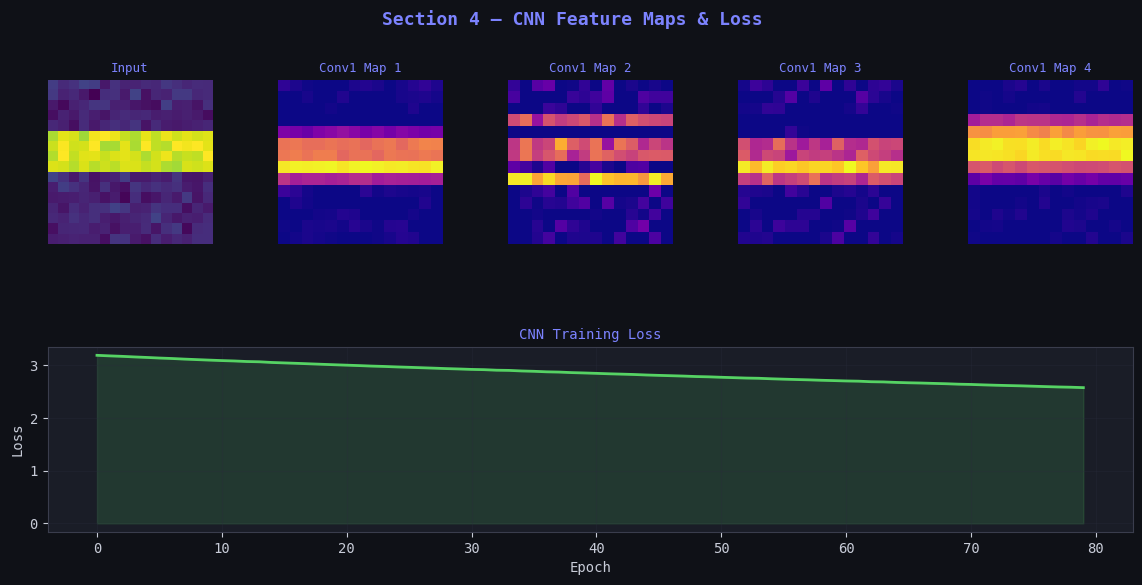

In [13]:
_ = cnn.forward(X_img[0:1])   # run one sample to get feature maps

fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Section 4 — CNN Feature Maps & Loss", fontsize=13,
             color=ACCENT, fontweight="bold")

gs = gridspec.GridSpec(2, 5, figure=fig, wspace=0.4, hspace=0.5)

# Input
ax = fig.add_subplot(gs[0, 0])
ax.set_facecolor("#1a1d27")
ax.imshow(X_img[0, 0], cmap="viridis")
ax.set_title("Input", color=ACCENT, fontsize=9); ax.axis("off")

# First 4 feature maps from conv block 1
for fi in range(4):
    ax = fig.add_subplot(gs[0, fi+1])
    ax.set_facecolor("#1a1d27")
    ax.imshow(cnn.r1[0, fi], cmap="plasma")
    ax.set_title(f"Conv1 Map {fi+1}", color=ACCENT, fontsize=9); ax.axis("off")

# Loss
ax_loss = fig.add_subplot(gs[1, :])
ax_loss.set_facecolor("#1a1d27")
ax_loss.plot(cnn_losses, color=GREEN, lw=2)
ax_loss.fill_between(range(len(cnn_losses)), cnn_losses, alpha=0.15, color=GREEN)
ax_loss.set_title("CNN Training Loss", color=ACCENT, fontsize=10)
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 🔑 Key Takeaways

| Concept | Detail |
|---|---|
| **Convolution** | Slide a small filter — detects local patterns |
| **Translation equivariance** | Same filter detects pattern anywhere in image |
| **im2col** | Reformulates conv as matrix multiply (fast!) |
| **Max pooling** | Downsample + approximate translation invariance |
| **Feature maps** | Each filter produces one "map" of its detected feature |
| **Parameter sharing** | One 3×3 filter covers entire image — 9 params vs. thousands |

➡️ **Next:** Section 5 introduces **Recurrent Neural Networks** for sequence data.
